In [4]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from accelerate.test_utils.testing import get_backend
from core.callbacks import WandBCallback
from lightning.pytorch.loggers import WandbLogger
from lightning import Trainer
from core.data import FullBatchDataModule
from core.estimators import BiasWithMSE, BiasWithAutodiffLoss #, BiasWithRidgeKernelMSE
from core.utils import rbf_kernel_torch, is_psd
from core.models import KernelRegression
from functools import partial
from lightning.pytorch.callbacks import EarlyStopping
device, n_devices, _ = get_backend()
# device = "cpu"
# n_devices = 1

torch.set_float32_matmul_precision("highest")

## Kernel Regression

In [28]:
# sinusoidal data
torch.manual_seed(56)
N = 200
p = 2 # input dimension / number of features
X = torch.randn(N, p)
betas = torch.ones(p)#3 * torch.randn(p)
y = torch.sin(X @ betas) + 0.1 * torch.randn(N)
dm_sin = FullBatchDataModule(X, y, num_workers=3)

In [32]:
eta = 1e-2 # learning rate
lambda_ = 0.1 # regularization parameter
gamma = 10. # width of the RBF kernel
# compute RBF kernel
pre_comp_K = rbf_kernel_torch(X=X, Y=X, gamma=gamma, eps=1e-8, enforce_psd=False)
assert is_psd(pre_comp_K, tol=1e-8), "Kernel is not positive semidefinite!"
# find max eigenvalue
eigenvalues = torch.linalg.eigvalsh(pre_comp_K @ pre_comp_K / N + lambda_ * pre_comp_K)
max_eigenvalue = eigenvalues.max().item()
min_eigenvalue = eigenvalues.min().item()
print(f"Max eigenvalue of C: {max_eigenvalue:.10f}")
print(f"Min eigenvalue of C: {min_eigenvalue:.10f}")
# learning rate condition
print(f"Max learning rate: {1. / max_eigenvalue:.10f}")
assert eta < 1. / max_eigenvalue, "Learning rate is too high!"

Matrix is symmetric.
Max eigenvalue of C: 1.7355530262
Min eigenvalue of C: 0.0000002249
Max learning rate: 0.5761852187


In [33]:
# Regression with RBF kernel
rbf_kernel_reg = KernelRegression(
    kernel_function=partial(rbf_kernel_torch, gamma=gamma),
    n_train_samples=N, 
    fit_intercept=False,
    ridge_lambda=lambda_,
    init_zeros=True,
    lr=eta  # no mismatch in lr for our derivation of kernel regression
)
# store the initial alphas
wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-regression", log_model=False
)

rbf_trainer = Trainer(
    max_epochs=1000,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=50, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
    # detect_anomaly=True,
)

rbf_trainer.fit(rbf_kernel_reg, dm_sin)
t = rbf_trainer.current_epoch

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | kernel_linear | Linear             | 200    | train
1 | loss_func     | KernelRidgeMSELoss | 0      | train
-------------------------------------------------------------
200       Trainable params
0         Non-trainable params
200       Total params
0.001     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

/home/jrudoler/inductive-bias/core/utils.py:137: UserWarning: Using the same X and Y, enforcing symmetry and positive semidefiniteness by adding 1e-06 on the diagonal.
  warnings.warn(
`Trainer.fit` stopped: `max_epochs=1000` reached.


epoch,▁▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train/loss,█▆▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇███
epoch,999
train/loss,0.40556
trainer/global_step,999


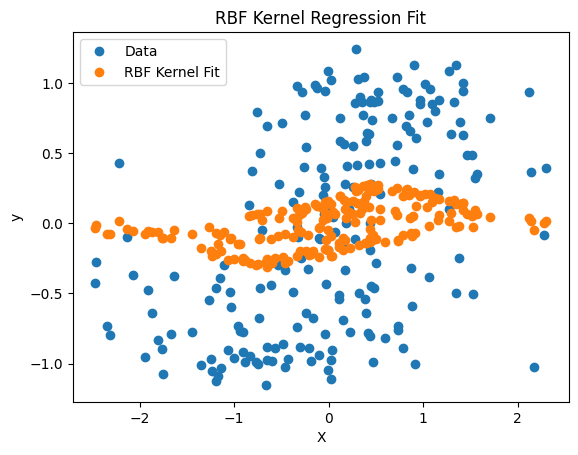

In [34]:
# plot the data and the RBF kernel regression fit
import matplotlib.pyplot as plt

plt.plot(X[:, 0], y, 'o', label='Data')
plt.plot(X[:, 0], rbf_kernel_reg(X).detach().numpy(), 'o', label='RBF Kernel Fit')
plt.title('RBF Kernel Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

In [35]:
K = rbf_kernel_torch(X, X, gamma=gamma)
assert torch.isfinite(K).all()
alpha = rbf_kernel_reg.kernel_linear.weight.detach().view(-1)
# print(f"RBF Kernel Regression alphas: \n{alpha}")

In [ ]:
# Estimate the quadratic form using the estimated Q from matrix ridge bias
from core.bias import DiagMatrixBiasKRR

## .detach() is essential here to detach the predictive model from the graph
alpha_init = rbf_kernel_reg.init_weights.view(-1).detach().clone()

# Use vanilla MSE loss, additional regularization is handled by the bias model
rbf_estimator = BiasWithMSE(
    predictive_model=rbf_kernel_reg,
    bias_model=DiagMatrixBiasKRR(
        Q_t_init=None,  # will be initialized as zeros
        dim=N,
        t=t,
        K=K,
        alpha_init=alpha_init,
        eta=eta,
        lambda_=lambda_,
    ),
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-bias", log_model=False
)
rbf_trainer = Trainer(
    max_epochs=1200,
    accumulate_grad_batches=1,
    log_every_n_steps=5,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=50, mode="min"),
    ],
    accelerator="gpu",
    devices=n_devices,
)
rbf_trainer.fit(rbf_estimator, dm_sin)

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | predictive_model | KernelRegression  | 200    | train
1 | bias_model       | DiagMatrixBiasKRR | 200    | train
---------------------------------------------------------------
400       Trainable params
0         Non-trainable params
400       Total params
0.002     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

/home/jrudoler/inductive-bias/core/utils.py:137: UserWarning: Using the same X and Y, enforcing symmetry and positive semidefiniteness by adding 1e-06 on the diagonal.
  warnings.warn(


In [22]:
from typing import Optional
def compute_kernel_ridge_Q_omega(K: torch.Tensor, eta: float, t: int, lambda_: float, alpha_init: torch.Tensor, device: Optional[str] = None) -> torch.Tensor:
    """
    Compute the Q matrix for kernel ridge regression.
    """
    if device is None:
        device = K.device
    K = K.to(device)
    alpha_init = alpha_init.to(device)
    dim = K.shape[0]
    I = torch.eye(dim, device=device)
    C = (1. / dim) * (K @ K) + lambda_ * K
    A = I - 2 * eta * C
    A_t = torch.linalg.matrix_power(A, t)
    Q_t = C @ (torch.linalg.inv(I - A_t) - I)

    omega_t = (C + Q_t) @ A_t @ alpha_init 

    return Q_t, omega_t

def compute_alpha_closed_form(K: torch.Tensor, y: torch.Tensor, Q: torch.Tensor, omega: torch.Tensor, lambda_: float) -> torch.Tensor:
    """
    Compute the closed-form solution for alpha using the kernel matrix K.
    """
    n = K.shape[0]
    C = (1 / n) * K @ K + lambda_ * K
    rhs = omega + (1 / n) * K @ y
    lhs = C + Q
    alpha = torch.linalg.solve(lhs, rhs)
    return alpha

# computations has to happen on the same device as the estimation or matrix computations
# will yield different results
Q_kernel_ridge, omega_kernel_ridge = compute_kernel_ridge_Q_omega(K, eta=eta, t=t, lambda_=lambda_, alpha_init=alpha_init, device=device)
Q_kernel_ridge = Q_kernel_ridge.detach().cpu().clone()
omega_kernel_ridge = omega_kernel_ridge.detach().cpu().clone()

In [23]:
Q_hat_kernel_ridge = torch.diag(rbf_estimator.bias_model.Q_t.detach())
print("estimated Q from kernel ridge bias:\n", Q_hat_kernel_ridge)
# now estimate the quadratic form using the estimated Q from kernel bias
print("theoretical Q from kernel ridge regression:\n", Q_kernel_ridge)

estimated Q from kernel ridge bias:
 tensor([[0.6650, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4008, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6255,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.6461, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.7285, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.5462]])
theoretical Q from kernel ridge regression:
 tensor([[ 9.4512e-01,  3.5405e-05,  1.2279e-05,  ..., -3.0943e-02,
          6.3301e-10,  1.4067e-04],
        [-1.8311e-04,  9.2578e-01, -1.0681e-04,  ...,  1.4038e-03,
         -1.8626e-07, -1.3428e-03],
        [-1.6117e-04, -1.4114e-04,  9.3427e-01,  ...,  2.3270e-04,
         -1.1991e-08, -1.6113e-02],
        ...,
        [-3.4691e-02, -3.6659e-03, -4.3058e-04,  ...,  9.6091e-01,
         -6.9791e-08, -3.9120e-03],
        [ 9.9244e-09,  3.2037e-07,  1.2995e-08,  ..., -4.2026e-08,
          9.4817e-01,  8.917

In [24]:
# Compare the estimated Q from kernel bias with the one from kernel regression
theory_alpha = compute_alpha_closed_form(K = K, y= y, Q=Q_kernel_ridge, omega=torch.zeros(N), lambda_=lambda_)
estimated_alpha = compute_alpha_closed_form(K = K, y= y, Q=Q_hat_kernel_ridge, omega=torch.zeros(N), lambda_=lambda_)
print("theoretical alpha from Q bias:\n", theory_alpha[:25])
print("estimated alpha from Q bias:\n", estimated_alpha[:25])
print("ground truth alpha:\n", alpha[:25])

theoretical alpha from Q bias:
 tensor([-0.0196,  0.0131, -0.0229, -0.0237, -0.0036, -0.0072,  0.0102, -0.0106,
        -0.0181, -0.0078, -0.0082, -0.0166,  0.0088, -0.0212, -0.0081, -0.0040,
        -0.0207, -0.0050,  0.0132,  0.0165,  0.0060, -0.0085,  0.0064,  0.0146,
         0.0021])
estimated alpha from Q bias:
 tensor([-0.0196,  0.0130, -0.0229, -0.0237, -0.0036, -0.0072,  0.0102, -0.0105,
        -0.0181, -0.0078, -0.0083, -0.0166,  0.0088, -0.0212, -0.0081, -0.0041,
        -0.0208, -0.0050,  0.0132,  0.0165,  0.0009, -0.0085,  0.0064,  0.0147,
         0.0021])
ground truth alpha:
 tensor([-0.0196,  0.0130, -0.0229, -0.0237, -0.0036, -0.0072,  0.0102, -0.0105,
        -0.0181, -0.0078, -0.0083, -0.0166,  0.0088, -0.0212, -0.0081, -0.0041,
        -0.0208, -0.0050,  0.0132,  0.0165,  0.0009, -0.0085,  0.0064,  0.0147,
         0.0021])


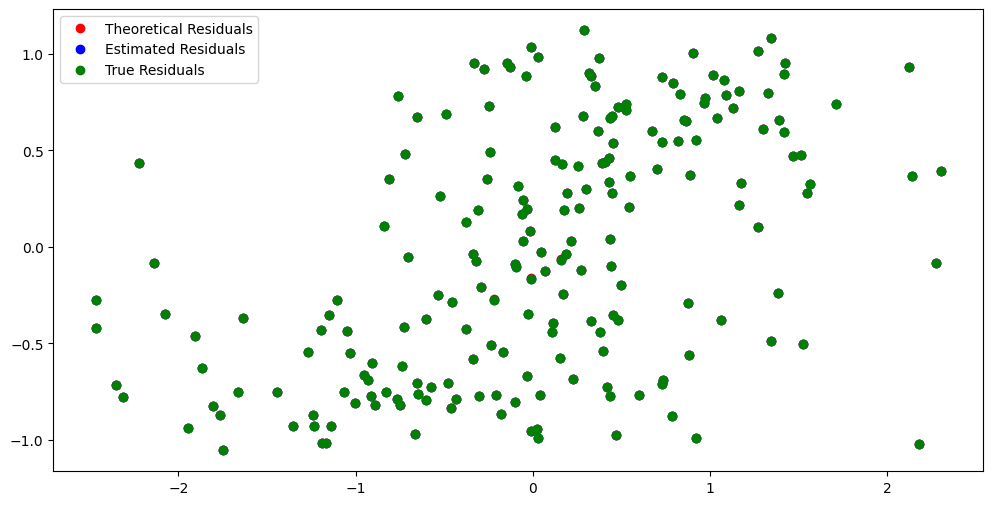

In [25]:
# predictions from the bias model
theory_resid = y - (theory_alpha @ K)
estimated_resid = y - (estimated_alpha @ K)
true_resid = y - (alpha @ K)
plt.figure(figsize=(12, 6))
plt.plot(X[:, 0], theory_resid, 'o', color="red", label='Theoretical Residuals')
plt.plot(X[:, 0], estimated_resid, 'o', color="blue", label='Estimated Residuals')
plt.plot(X[:, 0], true_resid, 'o', color="green", label='True Residuals')
plt.legend()

In [26]:
# compare RMSE
from sklearn.metrics import mean_squared_error
theory_rmse = mean_squared_error(y, theory_resid)
estimated_rmse = mean_squared_error(y, estimated_resid)
true_rmse = mean_squared_error(y, true_resid)
print(f"Theoretical RMSE: {theory_rmse:.4f}")
print(f"Estimated RMSE: {estimated_rmse:.4f}")
print(f"True RMSE: {true_rmse:.4f}")

Theoretical RMSE: 0.0088
Estimated RMSE: 0.0088
True RMSE: 0.0088


In [27]:
from core.utils import is_psd

print("Is the estimated Q positive semidefinite?", is_psd(Q_hat_kernel_ridge))
print("Is the theoretical Q positive semidefinite?", is_psd(Q_kernel_ridge))

Matrix is symmetric.
Is the estimated Q positive semidefinite? False
Matrix is not symmetric.
Is the theoretical Q positive semidefinite? False


In [25]:
1/torch.linalg.eigvalsh(Q_kernel_ridge).max()

tensor(0.0025)

In [26]:
import torch

## Device matters!!! GPU vs CPU can use different precision and yield different results

def compare_Q_matrices(
    K: torch.Tensor,
    eta: float,
    t: int,
    lambda_: float,
    alpha_init: torch.Tensor,
    atol: float = 1e-8
) -> None:
    n = K.size(0)
    # 1) exact from the standalone function
    Q_func, _ = compute_kernel_ridge_Q_omega(K, eta, t, lambda_, alpha_init)

    # 2) exact from the class
    model = DiagMatrixBiasKRR(
        dim=n, t=t, K=K, alpha_init=alpha_init,
        eta=eta, lambda_=lambda_
    )
    model = model  # Ensure the model is on the same device
    # forward just to populate model.Q_t_exact
    _ = model(alpha_init)

    Q_cls = model.Q_t_exact.detach()
    print(n)
    print(model.dim)
    print(model.t)
    diff = (Q_func - Q_cls).abs().max().item()

    print(f"max|Q_func – Q_cls| = {diff:.3e}")
    if diff < atol:
        print("✅ They match to within tolerance")
    else:
        print("❌ Mismatch—check your λ, t, dtype or device")

def compare_Q_matrices_gpu(
    K: torch.Tensor,
    eta: float,
    t: int,
    lambda_: float,
    alpha_init: torch.Tensor,
    atol: float = 1e-8
) -> None:
    n = K.size(0)
    K = K.double().to("cuda")  # Ensure K is on the same device
    alpha_init = alpha_init.double().to("cuda")  # Ensure alpha_init is on
    # 1) exact from the standalone function
    Q_func, _ = compute_kernel_ridge_Q_omega(K, eta, t, lambda_, alpha_init, device="cuda")

    # 2) exact from the class
    model = DiagMatrixBiasKRR(
        dim=n, t=t, K=K, alpha_init=alpha_init,
        eta=eta, lambda_=lambda_
    )
    model = model.double().to("cuda")  # Ensure the model is on the same device
    # forward just to populate model.Q_t_exact
    _ = model(alpha_init.double())

    Q_cls = model.Q_t_exact.detach()
    print(n)
    print(model.dim)
    print(model.t)
    diff = (Q_func - Q_cls).abs().max().item()

    print(f"max|Q_func – Q_cls| = {diff:.3e}")
    if diff < atol:
        print("✅ They match to within tolerance")
    else:
        print("❌ Mismatch—check your λ, t, dtype or device")

# Example usage:
# torch.manual_seed(0)
# n = 5
# K = torch.rand(n, n)
# K = K @ K.t()  # make it SPD
# α0 = torch.randn(N)
compare_Q_matrices(K, eta=eta, t=t, lambda_=lambda_, alpha_init=alpha_init)

[func]  n=200, η=0.0001, t=500, λ=0.1
tensor(195.2197)
[class (init)] dim=200, η=0.0001, t=500, λ=0.1
[class (forward)] K dtype: torch.float32, device: cpu
[class (forward)] K first few entries: tensor([[1.0000e+00, 8.4391e-06, 2.9980e-01, 4.7384e-02, 3.9685e-04],
        [8.4391e-06, 1.0000e+00, 1.3953e-09, 2.6154e-12, 6.8135e-01],
        [2.9980e-01, 1.3953e-09, 1.0000e+00, 6.5650e-01, 2.5557e-07],
        [4.7384e-02, 2.6154e-12, 6.5650e-01, 1.0000e+00, 1.0701e-09],
        [3.9685e-04, 6.8135e-01, 2.5557e-07, 1.0701e-09, 1.0000e+00]])
[class (forward)] K norm: 69.55648803710938
[class] dim=200, η=0.0001, t=500, λ=0.1
[class] Q_t_exact norm: 195.21971130371094
200
200
500
max|Q_func – Q_cls| = 0.000e+00
✅ They match to within tolerance


In [22]:
torch.sum(alpha**2 * rbf_estimator.bias_model.Q_t)

tensor(0.0353, grad_fn=<SumBackward0>)

In [24]:
alpha @ torch.diag(rbf_estimator.bias_model.Q_t) @ alpha

tensor(0.0353, grad_fn=<DotBackward0>)

In [27]:
is_psd(K)

False

In [30]:
torch.linalg.eigvalsh(K)

tensor([-4.2278e-06, -3.7398e-06, -3.5275e-06, -3.2642e-06, -3.0206e-06,
        -2.8890e-06, -2.7062e-06, -2.6365e-06, -2.4180e-06, -2.3674e-06,
        -2.2780e-06, -2.1824e-06, -2.1153e-06, -2.0686e-06, -1.9808e-06,
        -1.9400e-06, -1.8415e-06, -1.7517e-06, -1.6769e-06, -1.6501e-06,
        -1.5380e-06, -1.5209e-06, -1.4279e-06, -1.3464e-06, -1.3350e-06,
        -1.2380e-06, -1.1822e-06, -1.1656e-06, -9.8650e-07, -9.2748e-07,
        -9.0384e-07, -8.6226e-07, -8.1511e-07, -7.9732e-07, -7.6644e-07,
        -7.0484e-07, -6.9799e-07, -6.8466e-07, -6.5169e-07, -6.1143e-07,
        -5.5264e-07, -5.3171e-07, -5.2160e-07, -4.9082e-07, -4.8148e-07,
        -4.7647e-07, -4.5490e-07, -4.4043e-07, -4.0963e-07, -3.8950e-07,
        -3.7814e-07, -3.5214e-07, -3.3913e-07, -3.3207e-07, -3.1687e-07,
        -3.0868e-07, -2.8017e-07, -2.7433e-07, -2.6088e-07, -2.4885e-07,
        -2.2795e-07, -2.0305e-07, -1.9498e-07, -1.8630e-07, -1.7050e-07,
        -1.5138e-07, -1.5024e-07, -1.3722e-07, -1.0

In [47]:
is_psd(rbf_kernel_torch(X, gamma=0.))

False

In [27]:
import torch
import warnings
from torch import Tensor
from typing import Optional


def is_psd(matrix: Tensor, tol: float = 1e-5) -> bool:
    """Check if a symmetric matrix is positive semidefinite (PSD)."""
    if not torch.allclose(matrix, matrix.T, atol=tol):
        print("Matrix is not symmetric.")
        return False
    else:
        print("Matrix is symmetric.")
    try:
        # Eigenvalues should be >= -tol for numerical stability
        eigvals = torch.linalg.eigvalsh(matrix)
        return torch.all(eigvals >= -tol).item()
    except RuntimeError:
        return False
    
def rbf_kernel_torch(
    X: Tensor, Y: Optional[Tensor] = None, 
    gamma: Optional[float] = None, 
    enforce_psd: bool = True,
    eps: float = 1e-6
) -> Tensor:
    """
    Compute the RBF (Gaussian) kernel between X and Y:
      K[i,j] = exp(-gamma * ||X[i] - Y[j]||^2)

    If Y is None, uses Y = X.
    If gamma is None, defaults to 1.0 / n_features.
    """
    if Y is None:
        Y = X
    # default gamma = 1/n_features
    n_features = X.size(1)
    if gamma is None:
        gamma = 1.0 / float(n_features)
    if gamma < 0.0:
        raise ValueError(f"gamma must be non-negative, got {gamma}")

    # ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x·y
    X_norm = (X**2).sum(dim=1, keepdim=True)  # (n_X, 1)
    Y_norm = (Y**2).sum(dim=1, keepdim=True).t()  # (1, n_Y)
    sq_dists = X_norm + Y_norm - 2.0 * X @ Y.t()  # (n_X, n_Y)
    # sq_dists = torch.cdist(X, Y, p=2) ** 2  # (n_X, n_Y)
    K = torch.exp(-gamma * sq_dists)

    if enforce_psd and (Y is X):
        warnings.warn(
            f"Using the same X and Y, enforcing symmetry and positive semidefiniteness by adding {eps} on the diagonal.",
            UserWarning
        )
        # enforce perfect symmetry
        K = 0.5 * (K + K.t())
        # add a tiny diagonal bump so all eigenvalues ≥ 0
        K = K + eps * torch.eye(K.size(0), device=K.device, dtype=K.dtype)
    return K


torch.manual_seed(56)
N = 200
p = 2 # input dimension / number of features
X = torch.randn(N, p)
gamma = 1.0  # width of the RBF kernel

K = rbf_kernel_torch(X, gamma=gamma, eps=1e-5)
assert torch.isfinite(K).all()
assert is_psd(K, tol=1e-8)


Matrix is symmetric.


/tmp/ipykernel_1466433/1797175473.py:51: UserWarning: Using the same X and Y, enforcing symmetry and positive semidefiniteness by adding 1e-05 on the diagonal.
  warnings.warn(
